# Analysis of survey responses
Felix Zaussinger | 08.09.2022

**Core Analysis Goal(s)**
1. Download survey responses via Qualtrics API
2. Merge responses into single file and join GBN classification
3. Create plots to visualize agreement with GBN classification

**Key Insight(s)**
1.
2.
3.

In [14]:
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from src import utils, plotting_utils, stats_utils

# import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("paper")
# sns.set(rc={'figure.figsize': (16, 9.)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)
pd.options.display.float_format = "{:,.2f}".format

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Data preprocessing

In [15]:
download_and_preprocess = False

In [16]:
fpath_raw = os.path.join(useful_paths.data_processed, "survey", "survey_data_raw.csv")
fpath_fmt = os.path.join(
    useful_paths.data_processed, "survey", "survey_data_interim.csv"
)
fpath_final = os.path.join(
    useful_paths.data_processed, "survey", "survey_data_processed.csv"
)

#### Read final classifications

In [17]:
df_sl = pd.read_csv(
    os.path.join(
        useful_paths.data_processed,
        "esco",
        "esco_level_gbn_classification_short_lists.csv",
    ),
    index_col=0,
)

df_sl_tobi = pd.read_csv(
    os.path.join(
        useful_paths.data_processed,
        "esco",
        "esco_level_gbn_classification_short_lists_tobi.csv",
    ),
    index_col=0,
)

Strip whitespace and replace new lines from occupation descriptions

In [18]:
df_sl["description"] = df_sl["description"].str.strip().replace("\n", "", regex=True)
df_sl_tobi["description"] = (
    df_sl_tobi["description"].str.strip().replace("\n", "", regex=True)
)

#### Import contact list with survey id's

In [19]:
contact_list = pd.read_excel(
    os.path.join(useful_paths.data_processed, "survey", "contact_list_survey_v2.xlsx"),
    sheet_name="Survey Links",
)
contact_list

,sample_version,sample_name,survey_name,survey_link,survey_id,random_assignment,random_assignment_corr,email_sent,response,done,note,deadline
0,test_set_v4,test_set_shuffled_1,Green-Occupations_test_set_shuffled_1,https://descil.eu.qualtrics.com/jfe/form/SV_8A...,SV_8AnGiDhFo6NHmuy,EMPL-ESCO-SECRETARIAT@ec.europa.eu,marieke.vandeweyer@oecd.org,Y,Y,NaN,NaN,NaT
1,test_set_v4,test_set_shuffled_2,Green-Occupations_test_set_shuffled_2,https://descil.eu.qualtrics.com/jfe/form/SV_1Z...,SV_1ZcgN17YT4K4ckK,Stelina.Chatzichristou@cedefop.europa.eu,Abdelfeteh.BITAT@ec.europa.eu,Y,NaN,NaN,NaN,NaT
2,test_set_v4,test_set_shuffled_3,Green-Occupations_test_set_shuffled_3,https://descil.eu.qualtrics.com/jfe/form/SV_8B...,SV_8B2nwzLWJJK012S,cath.sleeman@nesta.org.uk,markus.janser@iab.de,Y,Y,NaN,NaN,NaT
3,test_set_v4,test_set_shuffled_4,Green-Occupations_test_set_shuffled_4,https://descil.eu.qualtrics.com/jfe/form/SV_08...,SV_08SzuShq3d0bTHE,markus.janser@iab.de,davide.consoli@ingenio.upv.es,Y,NaN,Y,NaN,NaT
4,test_set_v4,test_set_shuffled_5,Green-Occupations_test_set_shuffled_5,https://descil.eu.qualtrics.com/jfe/form/SV_56...,SV_56bMHSHFEYef2MC,montt@ilo.org,Stelina.Chatzichristou@cedefop.europa.eu,Y,Declined,NaN,3 partial responses,NaT
5,test_set_v4,test_set_shuffled_6,Green-Occupations_test_set_shuffled_6,https://descil.eu.qualtrics.com/jfe/form/SV_eU...,SV_eURBW8C8gggqXxs,u.scharf@skilllab.io,valeria.costantini@uniroma3.it,Y,Y,Y,NaN,NaT
6,test_set_v4,test_set_shuffled_7,Green-Occupations_test_set_shuffled_7,https://descil.eu.qualtrics.com/jfe/form/SV_7O...,SV_7O0vzMVe4r4VEXQ,s.schmid@skilllab.io,s.schmid@skilllab.io,Y,Y,NaN,NaN,NaT
7,test_set_v4,test_set_shuffled_8,Green-Occupations_test_set_shuffled_8,https://descil.eu.qualtrics.com/jfe/form/SV_0c...,SV_0c97zs7xtCbhvr8,elisa.lanzi@oecd.org,Matteo.SOSTERO@ec.europa.eu,Y,NaN,NaN,NaN,NaT
8,test_set_v4,test_set_shuffled_9,Green-Occupations_test_set_shuffled_9,https://descil.eu.qualtrics.com/jfe/form/SV_cF...,SV_cFUdmL9WmkTECa2,valeria.costantini@uniroma3.it,montt@ilo.org,Y,NaN,NaN,NaN,NaT
9,test_set_v4,test_set_shuffled_10,Green-Occupations_test_set_shuffled_10,https://descil.eu.qualtrics.com/jfe/form/SV_be...,SV_behR8jDZYKRWfMq,Vlasis.KOROVILOS@cedefop.europa.eu,EMPL-ESCO-SECRETARIAT@ec.europa.eu,Y,NaN,NaN,NaN,NaT


#### Setup Qualtrics API connection

In [20]:
if download_and_preprocess:
    # 1) Setup Qualtrics API connection
    # ----------------------------------------------------------------------------------
    from QualtricsAPI.Setup import Credentials
    from QualtricsAPI.Survey import Responses

    responses = Responses()

    # Call the qualtrics_api_credentials() method (Non-XM Directory Users)
    Credentials().qualtrics_api_credentials(
        token="r6EycR7p7xwUqMJtYKEZO8NvVsyeQJmjKj7u5uJB", data_center="fra1"
    )

    # 2) Iteratively download raw responses
    # ----------------------------------------------------------------------------------
    header = None
    response_container = []
    for i, survey_id in enumerate(contact_list.survey_id):
        print("downloading survey: {}/{}".format(i + 1, len(contact_list.survey_id)))
        # Get Survey Responses (Updated)
        response = responses.get_survey_responses(survey=survey_id, useLabels=True)

        # append nan row for empty responses
        if response.shape[0] < 3:
            response.loc[2, :] = np.nan

        # set survey id
        response["SurveyId"] = survey_id

        response_container.append(response)

    # 3) Clean raw data
    # ----------------------------------------------------------------------------------

    # reset index to obtain row id's
    df_raw = pd.concat(response_container).reset_index()
    df_raw = df_raw.rename(columns={"index": "RowId"})

    # drop rows with dict's
    df_clean = df_raw[df_raw["RowId"] != 1]

    # drop cols we don't need, rename
    cols2drop = [
        "RecipientLastName",
        "RecipientFirstName",
        "RecipientEmail",
        "ExternalReference",
        "Q1.1",
    ]
    rename_dict = {
        "Q2.1": "RecipientName",
        "Q2.2": "RecipientEmail",
        "Q2.3": "RecipientInstitution",
    }
    df_clean = df_clean.drop(columns=cols2drop)
    df_clean = df_clean.rename(columns=rename_dict)
    df_clean = df_clean.drop_duplicates()

    # 4) Delete introductory text
    # ----------------------------------------------------------------------------------
    # this snippet needs to be deleted from every occupation description (drop down menu
    # from survey)
    del_desc = "\n\n\n\n\nDisplay definitions\n\n\nDefinitions:\n\nGreen occupations: contribute to decreasing the negative impact of human activity on the environment (e.g., through reducing GHG emissions, air- & water-pollution, restoring ecosystems or enhancing biodiversity) or to enabling the green transition (e.g., through expanding the electricity transmission & distribution network), and are predominantly found in key green economy sectors (e.g., Renewable Energy Generation, Energy Efficiency, Environment Protection, Recycling and Waste Reduction, Water Supply).\nBrown occupations: contribute to maintaining or increasing the negative impact of human activity on the environment (e.g., through emitting GHG's, causing air- & water-pollution, damaging ecosystems or reducing biodiversity) and are predominantly found in sectors with above-average emission & pollution intensities (e.g., Mining, Oil and Gas Extraction, Manufacturing).\nNeutral occupations: neither contribute to significantly decreasing nor increasing the negative impact of human activity on the environment and neither affect the direction nor speed of the green transition to a first order (e.g., Hairdressers, Translators)."

    for i in range(1, 31):
        df_clean["{}".format(i)] = df_clean["{}".format(i)].str.replace(
            pat=del_desc, repl="", regex=False
        )

    # 5) organise occupation columns as (str_description, str_choice) tuples
    # ----------------------------------------------------------------------------------
    response_container_fmt = []
    for i, (id, grp) in enumerate(df_clean.groupby("SurveyId")):
        grp = grp.set_index("RowId")

        # convert to tuples
        for i in range(1, 31):
            grp.loc[2, "{}".format(i)] = (
                grp.loc[0, "{}".format(i)],
                grp.loc[2, "{}".format(i)],
            )
            grp_new = grp.loc[2, :]

        # convert/transpose
        if isinstance(grp_new, pd.Series):
            grp_out = grp_new.to_frame().T
        else:
            raise Exception("check")
        grp_out.index = [i]

        response_container_fmt.append(grp_out)

    # combine and drop missing surveys
    df_clean_fmt = pd.concat(response_container_fmt, axis=0)
    df_clean_fmt = df_clean_fmt.dropna(subset=["RecipientName"])

    # 6) Descriptive statistics of survey metadata
    # ----------------------------------------------------------------------------------
    df_clean_fmt["Duration (in min)"] = (
        df_clean_fmt["Duration (in seconds)"].astype(float) / 60
    )
    df_clean_fmt["Q1.3_Page Submit (in min)"] = (
        df_clean_fmt["Q1.3_Page Submit"].astype(float) / 60
    )
    df_clean_fmt["Q2.4_Page Submit (in min)"] = (
        df_clean_fmt["Q2.4_Page Submit"].astype(float) / 60
    )
    df_clean_fmt["Duration Classification Task (in min)"] = (
        df_clean_fmt["Duration (in min)"]
        - df_clean_fmt["Q1.3_Page Submit (in min)"]
        - df_clean_fmt["Q2.4_Page Submit (in min)"]
    )

    # 7) Reshape data to long format: https://stackoverflow.com/questions/29550414/how-can-i-split-a-column-of-tuples-in-a-pandas-dataframe
    # ----------------------------------------------------------------------------------
    # find value and id cols
    occ_class_cols = ["{}".format(i) for i in range(1, 31)]
    keep_cols = set(df_clean_fmt.columns.values).difference(set(occ_class_cols))

    # melt
    df_clean_fmt_long = df_clean_fmt.melt(
        value_vars=occ_class_cols, id_vars=keep_cols
    ).sort_values("SurveyId")
    (
        df_clean_fmt_long["OccupationDescription"],
        df_clean_fmt_long["RecipientClassification"],
    ) = df_clean_fmt_long["value"].str
    df_clean_fmt_long = df_clean_fmt_long.drop(labels=["value", "variable"], axis=1)

    # 8) Join our classifications
    # ----------------------------------------------------------------------------------

    # Change individual occupation descriptions to match between the data sets
    manual_changes_to_occ_desc = {
        "Energy managers coordinate the energy use in an organisation, and aim to implement policies for increased sustainability, and minimisation of cost and environmental impact. They monitor the energy demands\nand use, and develop improvement strategies, as well as researching the most beneficial source of energy for the organisation's needs.": "Energy managers coordinate the energy use in an organisation, and aim to implement policies for increased sustainability, and minimisation of cost and environmental impact. They monitor the energy demands and use, and develop improvement strategies, as well as researching the most beneficial source of energy for the organisation's needs."
    }

    for txt_before, txt_after in manual_changes_to_occ_desc.items():
        df_clean_fmt_long.loc[
            df_clean_fmt_long["OccupationDescription"] == txt_before,
            "OccupationDescription",
        ] = txt_after

    df_sl_tobi.query("preferredLabel == 'energy manager'").description.values.tolist()

    # short list
    df_long_merged = pd.merge(
        df_clean_fmt_long,
        df_sl[["description", "gbn_classification_short_list"]],
        left_on="OccupationDescription",
        right_on="description",
        how="left",
    ).rename(columns={"gbn_classification_short_list": "EthClassificationWide"})

    # short list tobi
    df_long_merged = pd.merge(
        df_long_merged,
        df_sl_tobi[["description", "gbn_classification_short_list"]],
        left_on="OccupationDescription",
        right_on="description",
        how="left",
    ).rename(columns={"gbn_classification_short_list": "EthClassificationNarrow"})

    # redundant
    df_long_merged_clean = df_long_merged.drop(
        labels=["description_x", "description_y"], axis=1
    )

    # to lowercase
    df_long_merged_clean["RecipientClassification"] = df_long_merged_clean[
        "RecipientClassification"
    ].str.lower()
    print(df_long_merged_clean.shape)

    # 9) Create final data for analysis
    # ----------------------------------------------------------------------------------
    # drop RecipientClassification == unsure
    df_long_merged_clean_unsure_dropped = df_long_merged_clean[
        df_long_merged_clean["RecipientClassification"] != "unsure"
    ]
    print(
        "unsure answers: {:.2f}% of {}".format(
            100
            - 100
            * (
                df_long_merged_clean_unsure_dropped.shape[0]
                / df_long_merged_clean.shape[0]
            ),
            df_long_merged_clean.shape[0],
        )
    )

    df_long_merged_clean_unsure_dropped.shape

    missing_matches = df_long_merged_clean_unsure_dropped[
        pd.isna(df_long_merged_clean_unsure_dropped["EthClassificationWide"])
    ]
    missing_matches.to_csv(
        os.path.join(
            useful_paths.data_processed,
            "survey",
            "survey_data_interim_missing_matches.csv",
        )
    )

    # Check if all occupation descriptions were matched (!!!)
    assert missing_matches.shape[0] == 0

    # Drop answers where occupation descriptions could not be matched
    df_long_final = df_long_merged_clean_unsure_dropped.dropna(
        subset=["RecipientClassification"]
    )

    # 10) Save final data set
    # ----------------------------------------------------------------------------------

    df_raw.to_csv(fpath_raw)
    df_clean_fmt.to_csv(fpath_fmt)
    df_long_final.to_csv(fpath_final)

#### Read final data set

In [21]:
if not download_and_preprocess:
    df_long_final = pd.read_csv(fpath_final, index_col=0)

### Data Analysis

In [40]:
# drop outliers
response_data_sets = [None, ["Marieke Vandeweyer", "Madeline Tyson"]]

#### Calculate confusion matrix for both lists

true (rows), predicted (columns)

In [22]:
from sklearn import metrics

labels = ["green", "brown", "neutral"]

##### Wide

In [42]:
for drop_outlier_responses in response_data_sets:

    # optionally drop outliers
    if drop_outlier_responses is not None:
        df = df_long_final[~df_long_final["RecipientName"].isin(drop_outlier_responses)]
    else:
        df = df_long_final

    # wide
    cm_wide = metrics.confusion_matrix(
        y_true=df.EthClassificationWide,
        y_pred=df.RecipientClassification,
        labels=labels,
        normalize="true",
    )

    df_cm_wide = pd.DataFrame(cm_wide, columns=labels, index=labels)

    oA = metrics.accuracy_score(
        y_true=df.EthClassificationWide, y_pred=df.RecipientClassification
    )

    print(drop_outlier_responses)
    print(oA)
    print(df_cm_wide)
    print("")

None
0.7619047619047619
         green  brown  neutral
green     0.85   0.03     0.11
brown     0.02   0.61     0.37
neutral   0.10   0.09     0.81

['Marieke Vandeweyer', 'Madeline Tyson']
0.7919463087248322
         green  brown  neutral
green     0.88   0.04     0.08
brown     0.02   0.67     0.31
neutral   0.09   0.09     0.82



##### Narrow

In [43]:
for drop_outlier_responses in response_data_sets:

    # optionally drop outliers
    if drop_outlier_responses is not None:
        df = df_long_final[~df_long_final["RecipientName"].isin(drop_outlier_responses)]
    else:
        df = df_long_final

    # wide
    cm_narrow = metrics.confusion_matrix(
        y_true=df.EthClassificationNarrow,
        y_pred=df.RecipientClassification,
        labels=labels,
        normalize="true",
    )

    df_cm_wide = pd.DataFrame(cm_narrow, columns=labels, index=labels)

    oA = metrics.accuracy_score(
        y_true=df.EthClassificationNarrow, y_pred=df.RecipientClassification
    )

    print(drop_outlier_responses)
    print(oA)
    print(df_cm_wide)
    print("")

None
0.7579365079365079
         green  brown  neutral
green     0.85   0.03     0.11
brown     0.04   0.80     0.16
neutral   0.07   0.25     0.69

['Marieke Vandeweyer', 'Madeline Tyson']
0.7695749440715883
         green  brown  neutral
green     0.88   0.04     0.08
brown     0.04   0.90     0.06
neutral   0.06   0.26     0.67



In [36]:
metrics.accuracy_score(
    y_true=df_long_final.EthClassificationNarrow,
    y_pred=df_long_final.RecipientClassification,
)

0.7579365079365079

#### Calculate agreement rates per rater & category

Fraction of correctly classified samples across all 3 classes

In [25]:
keep_cols = [
    "SurveyId",
    "RecipientName",
    "RecipientInstitution",
    "RecipientEmail",
    "Duration Classification Task (in min)",
    "Q1.3_Page Submit (in min)",
    "Q2.4_Page Submit (in min)",
]

In [26]:
overall_accuracy = []
for id, df in df_long_final.groupby("SurveyId"):
    df_out = df.head(1)[keep_cols]
    df_out.loc[:, "AccuracyWide"] = metrics.accuracy_score(
        df.EthClassificationWide, df.RecipientClassification
    )
    df_out.loc[:, "AccuracyNarrow"] = metrics.accuracy_score(
        df.EthClassificationNarrow, df.RecipientClassification
    )

    overall_accuracy.append(df_out)

df_overall_accuracy = pd.concat(overall_accuracy, axis=0)
df_overall_accuracy

,SurveyId,RecipientName,RecipientInstitution,RecipientEmail,Duration Classification Task (in min),Q1.3_Page Submit (in min),Q2.4_Page Submit (in min),AccuracyWide,AccuracyNarrow
0,SV_08SzuShq3d0bTHE,Davide Consoli,INGENIO (CSIC-UPV),davide.consoli@ingenio.upv.es,3.67,0.12,0.44,0.62,0.48
30,SV_0Vuxf3vymniiKOO,Ulrich Scharf,SkillLab,u.scharf@skilllab.io,4.42,0.06,0.35,0.78,0.81
60,SV_0c97zs7xtCbhvr8,Matteo Sostero,"European Commission, Joint Research Centre",matteo.sostero@ec.europa.eu,9.56,0.25,0.55,0.86,0.79
90,SV_1ZcgN17YT4K4ckK,Abdelfeteh BITAT,European Commission,abdelfeteh.bitat@ec.europa.eu,4.06,0.05,0.37,0.68,0.86
120,SV_3EJUuyWm4Ipj274,Giovanni Marin,University of Urbino Carlo Bo,giovanni.marin@uniurb.it,5.65,3.13,0.25,0.89,0.86
150,SV_3Qnrn9FpJiti7yu,Federico Biagi,European Commission,Federico.BIAGI@ec.europa.eu,28.98,1.14,0.54,0.86,0.79
180,SV_4GB5Nh9wk8FgeRo,Elisa Lanzi,OECD,elisa.lanzi@oecd.org,8.38,0.20,0.28,0.93,0.82
210,SV_4YNE2rVWxk5pfzU,Madeline Tyson,RMI,mtyson@rmi.org,9.41,0.10,0.19,0.61,0.71
240,SV_6DSmFSXQBkWuzpI,Glenda Quintini,OECD,glenda.quintini@oecd.org,20.70,21.87,0.56,0.86,0.69
270,SV_7O0vzMVe4r4VEXQ,Simon Schmid,SkillLab,s.schmid@skilllab.io,4.25,0.16,3.30,0.71,0.89


Correlation between duration and accuracy

In [27]:
import pingouin as pg

df_overall_accuracy.rcorr(upper="pval", stars=True)

,Duration Classification Task (in min),Q1.3_Page Submit (in min),Q2.4_Page Submit (in min),AccuracyWide,AccuracyNarrow
Duration Classification Task (in min),-,*,,,
Q1.3_Page Submit (in min),0.496,-,,,
Q2.4_Page Submit (in min),-0.089,-0.013,-,,
AccuracyWide,0.222,0.169,-0.105,-,*
AccuracyNarrow,-0.067,-0.177,0.235,0.52,-


Fraction of correctly classified samples per class

In [28]:
accuracy_by_category_wide = []
reference_classification = "EthClassificationWide"

for id, df in df_long_final.groupby("SurveyId"):
    df_out = df.head(1)[keep_cols]

    for category, sub_df in df.groupby(reference_classification):
        df_out.loc[
            :, "Accuracy{}".format(category.capitalize())
        ] = metrics.accuracy_score(
            sub_df[reference_classification], sub_df.RecipientClassification
        )

    accuracy_by_category_wide.append(df_out)

df_accuracy_by_category_wide = pd.concat(accuracy_by_category_wide, axis=0)
df_accuracy_by_category_wide

,SurveyId,RecipientName,RecipientInstitution,RecipientEmail,Duration Classification Task (in min),Q1.3_Page Submit (in min),Q2.4_Page Submit (in min),AccuracyBrown,AccuracyGreen,AccuracyNeutral
0,SV_08SzuShq3d0bTHE,Davide Consoli,INGENIO (CSIC-UPV),davide.consoli@ingenio.upv.es,3.67,0.12,0.44,0.80,0.70,0.33
30,SV_0Vuxf3vymniiKOO,Ulrich Scharf,SkillLab,u.scharf@skilllab.io,4.42,0.06,0.35,0.62,0.90,0.78
60,SV_0c97zs7xtCbhvr8,Matteo Sostero,"European Commission, Joint Research Centre",matteo.sostero@ec.europa.eu,9.56,0.25,0.55,0.78,1.00,0.80
90,SV_1ZcgN17YT4K4ckK,Abdelfeteh BITAT,European Commission,abdelfeteh.bitat@ec.europa.eu,4.06,0.05,0.37,0.38,0.80,0.80
120,SV_3EJUuyWm4Ipj274,Giovanni Marin,University of Urbino Carlo Bo,giovanni.marin@uniurb.it,5.65,3.13,0.25,0.62,1.00,1.00
150,SV_3Qnrn9FpJiti7yu,Federico Biagi,European Commission,Federico.BIAGI@ec.europa.eu,28.98,1.14,0.54,0.78,0.89,0.90
180,SV_4GB5Nh9wk8FgeRo,Elisa Lanzi,OECD,elisa.lanzi@oecd.org,8.38,0.20,0.28,0.88,0.90,1.00
210,SV_4YNE2rVWxk5pfzU,Madeline Tyson,RMI,mtyson@rmi.org,9.41,0.10,0.19,0.12,0.60,1.00
240,SV_6DSmFSXQBkWuzpI,Glenda Quintini,OECD,glenda.quintini@oecd.org,20.70,21.87,0.56,0.90,0.89,0.80
270,SV_7O0vzMVe4r4VEXQ,Simon Schmid,SkillLab,s.schmid@skilllab.io,4.25,0.16,3.30,0.33,0.80,1.00


In [29]:
df_accuracy_by_category_wide.rcorr(upper="pval", stars=True)

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.0, the latest is 0.5.2.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


,Duration Classification Task (in min),Q1.3_Page Submit (in min),Q2.4_Page Submit (in min),AccuracyBrown,AccuracyGreen,AccuracyNeutral
Duration Classification Task (in min),-,*,,,,
Q1.3_Page Submit (in min),0.496,-,,,,
Q2.4_Page Submit (in min),-0.089,-0.013,-,,,
AccuracyBrown,0.245,0.254,-0.192,-,*,
AccuracyGreen,0.11,0.103,-0.122,0.578,-,
AccuracyNeutral,0.124,-0.013,0.163,-0.007,0.446,-


In [30]:
accuracy_by_category_narrow = []
reference_classification = "EthClassificationNarrow"

for id, df in df_long_final.groupby("SurveyId"):
    df_out = df.head(1)[keep_cols]

    for category, sub_df in df.groupby(reference_classification):
        df_out.loc[
            :, "Accuracy{}".format(category.capitalize())
        ] = metrics.accuracy_score(
            sub_df[reference_classification], sub_df.RecipientClassification
        )

    accuracy_by_category_narrow.append(df_out)

df_accuracy_by_category_narrow = pd.concat(accuracy_by_category_narrow, axis=0)
df_accuracy_by_category_narrow

,SurveyId,RecipientName,RecipientInstitution,RecipientEmail,Duration Classification Task (in min),Q1.3_Page Submit (in min),Q2.4_Page Submit (in min),AccuracyBrown,AccuracyGreen,AccuracyNeutral
0,SV_08SzuShq3d0bTHE,Davide Consoli,INGENIO (CSIC-UPV),davide.consoli@ingenio.upv.es,3.67,0.12,0.44,1.00,0.70,0.29
30,SV_0Vuxf3vymniiKOO,Ulrich Scharf,SkillLab,u.scharf@skilllab.io,4.42,0.06,0.35,1.00,0.90,0.71
60,SV_0c97zs7xtCbhvr8,Matteo Sostero,"European Commission, Joint Research Centre",matteo.sostero@ec.europa.eu,9.56,0.25,0.55,1.00,1.00,0.62
90,SV_1ZcgN17YT4K4ckK,Abdelfeteh BITAT,European Commission,abdelfeteh.bitat@ec.europa.eu,4.06,0.05,0.37,1.00,0.80,0.87
120,SV_3EJUuyWm4Ipj274,Giovanni Marin,University of Urbino Carlo Bo,giovanni.marin@uniurb.it,5.65,3.13,0.25,0.67,1.00,0.80
150,SV_3Qnrn9FpJiti7yu,Federico Biagi,European Commission,Federico.BIAGI@ec.europa.eu,28.98,1.14,0.54,1.00,0.89,0.69
180,SV_4GB5Nh9wk8FgeRo,Elisa Lanzi,OECD,elisa.lanzi@oecd.org,8.38,0.20,0.28,0.80,0.90,0.77
210,SV_4YNE2rVWxk5pfzU,Madeline Tyson,RMI,mtyson@rmi.org,9.41,0.10,0.19,0.20,0.60,1.00
240,SV_6DSmFSXQBkWuzpI,Glenda Quintini,OECD,glenda.quintini@oecd.org,20.70,21.87,0.56,1.00,0.89,0.53
270,SV_7O0vzMVe4r4VEXQ,Simon Schmid,SkillLab,s.schmid@skilllab.io,4.25,0.16,3.30,1.00,0.80,0.94


In [31]:
df_accuracy_by_category_narrow.rcorr(upper="pval", stars=True)

,Duration Classification Task (in min),Q1.3_Page Submit (in min),Q2.4_Page Submit (in min),AccuracyBrown,AccuracyGreen,AccuracyNeutral
Duration Classification Task (in min),-,*,,,,
Q1.3_Page Submit (in min),0.496,-,,,,
Q2.4_Page Submit (in min),-0.089,-0.013,-,,,
AccuracyBrown,-0.002,0.05,0.208,-,*,
AccuracyGreen,0.11,0.103,-0.122,0.499,-,
AccuracyNeutral,-0.125,-0.248,0.229,-0.321,-0.013,-


#### Save data

In [32]:
# analysis metrics
df_cm_wide.to_csv(os.path.join(useful_paths.figure_dir, "survey", "df_cm_wide.csv"))
df_cm_narrow.to_csv(os.path.join(useful_paths.figure_dir, "survey", "df_cm_narrow.csv"))
df_overall_accuracy.to_csv(
    os.path.join(useful_paths.figure_dir, "survey", "df_overall_accuracy.csv")
)
df_accuracy_by_category_wide.to_csv(
    os.path.join(useful_paths.figure_dir, "survey", "df_accuracy_by_category_wide.csv")
)
df_accuracy_by_category_narrow.to_csv(
    os.path.join(
        useful_paths.figure_dir, "survey", "df_accuracy_by_category_narrow.csv"
    )
)

### Visualisation

#### Confusion matrix

#### Overall accuracy per rater

<AxesSubplot:ylabel='Frequency'>

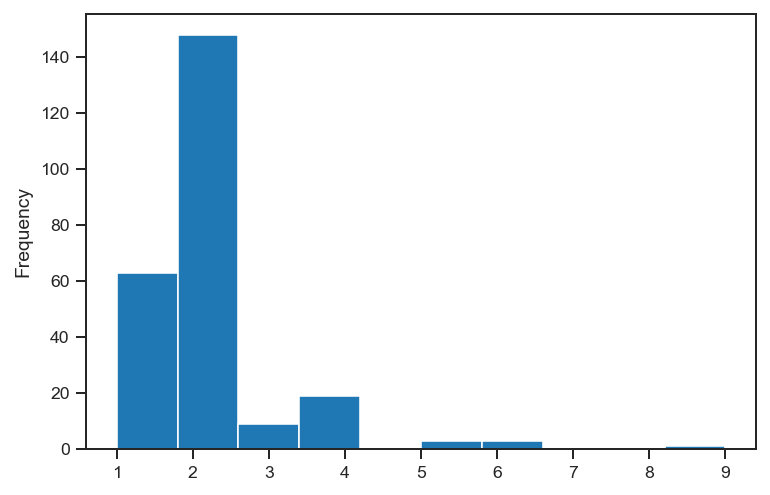

In [33]:
df_long_final.groupby("OccupationDescription").count()[
    "DistributionChannel"
].plot.hist()

#### Per-category accuracy

- swarmplot doesn't recognize hue when either the x or y parameter is omitted: https://github.com/mwaskom/seaborn/issues/941

Reference: Wide ETH classification (SL)

C:\Users\fzaussinger\AppData\Local\Temp\ipykernel_15844\2319005065.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\fzaussinger\AppData\Local\Temp\ipykernel_15844\2319005065.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\seaborn\cat

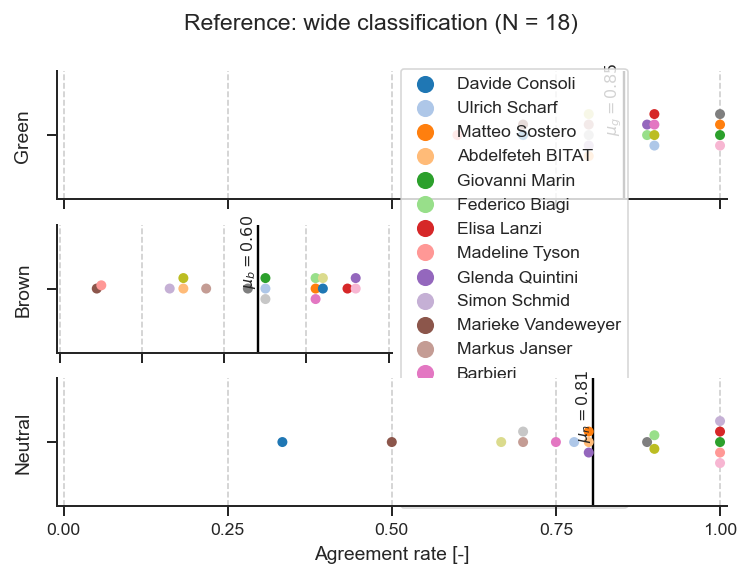

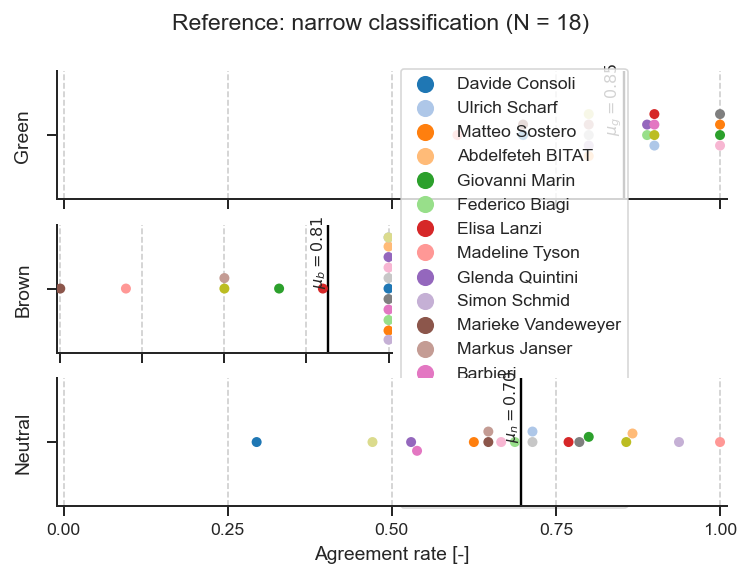

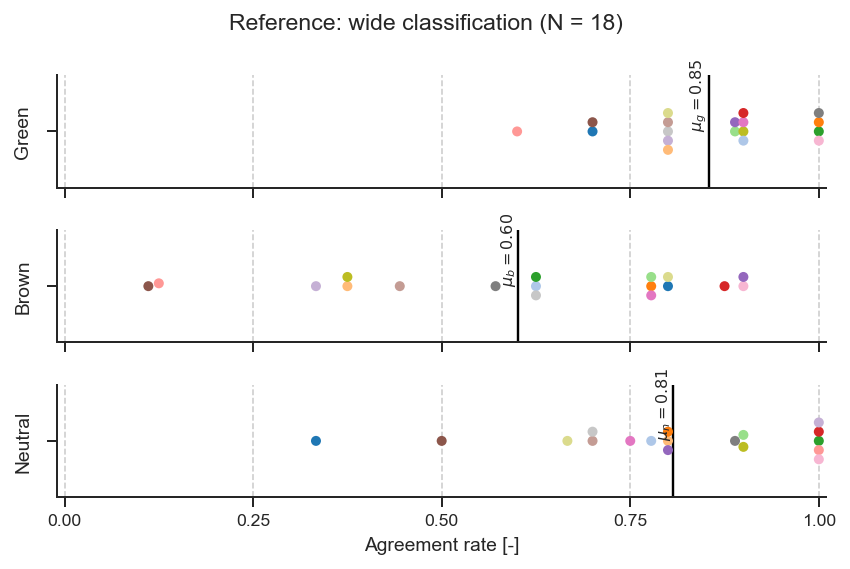

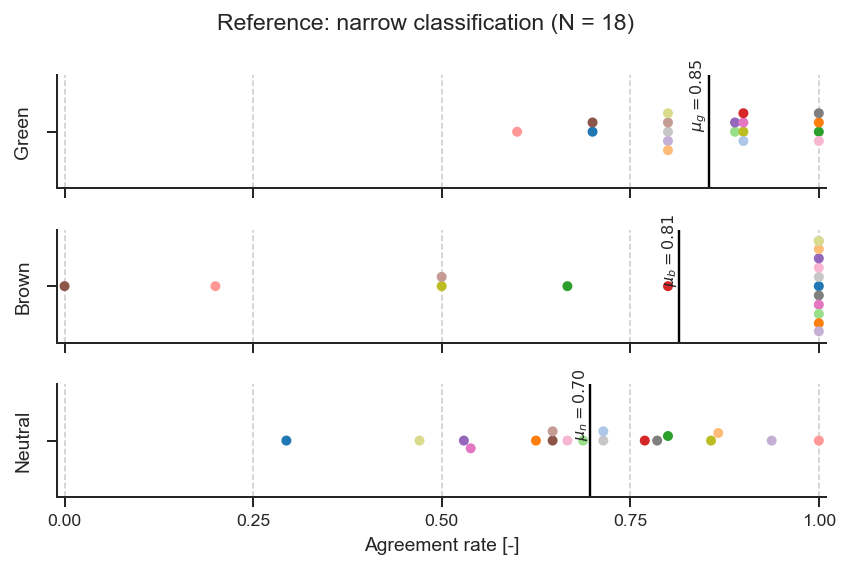

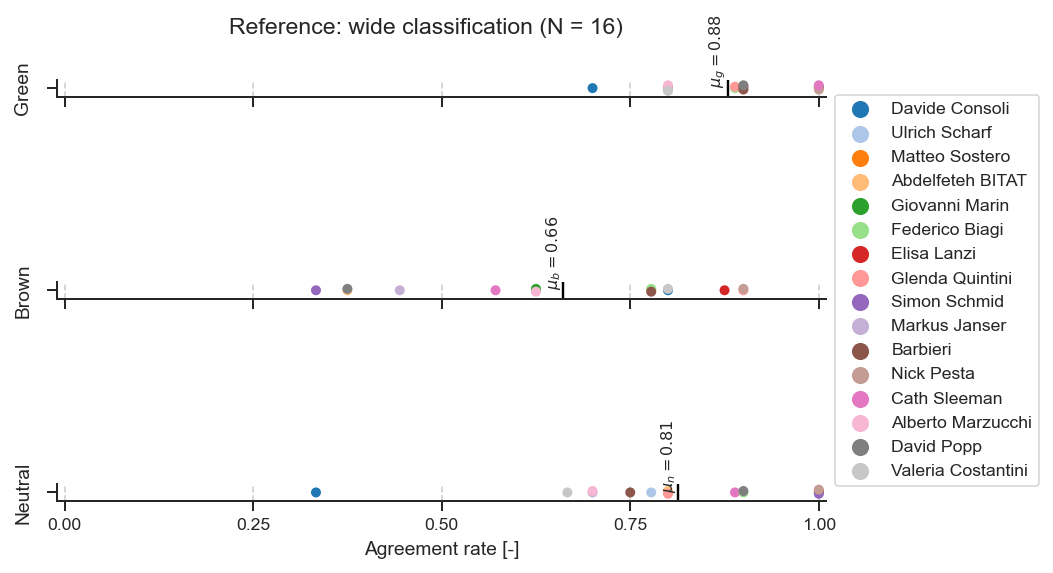

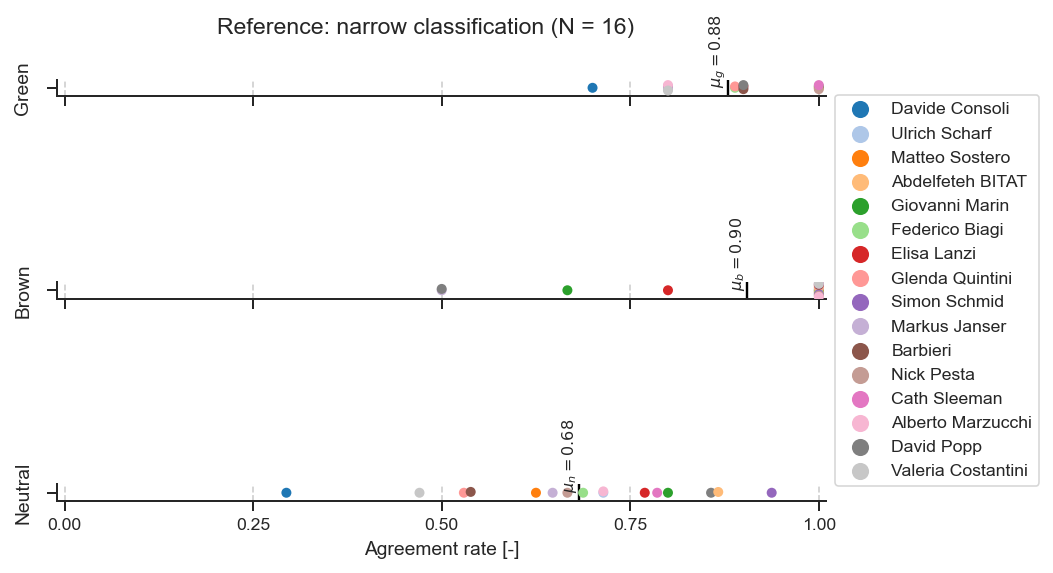

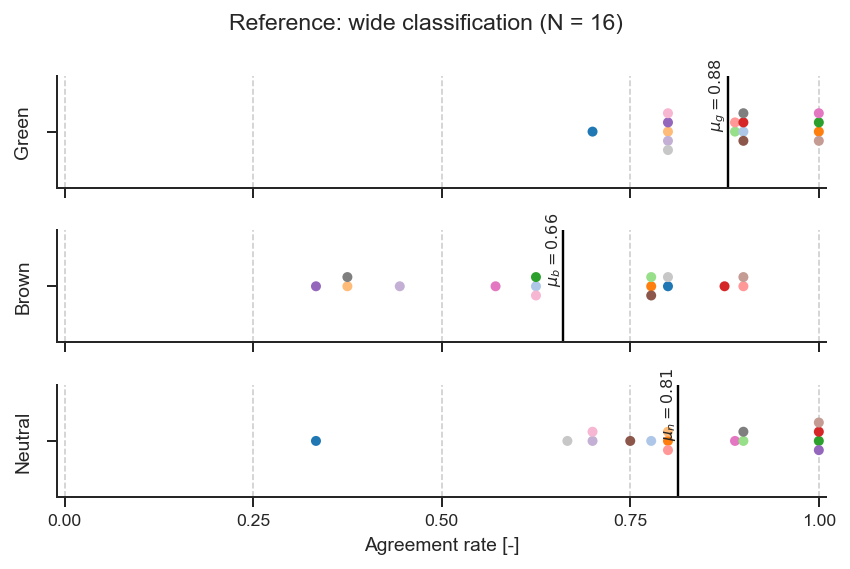

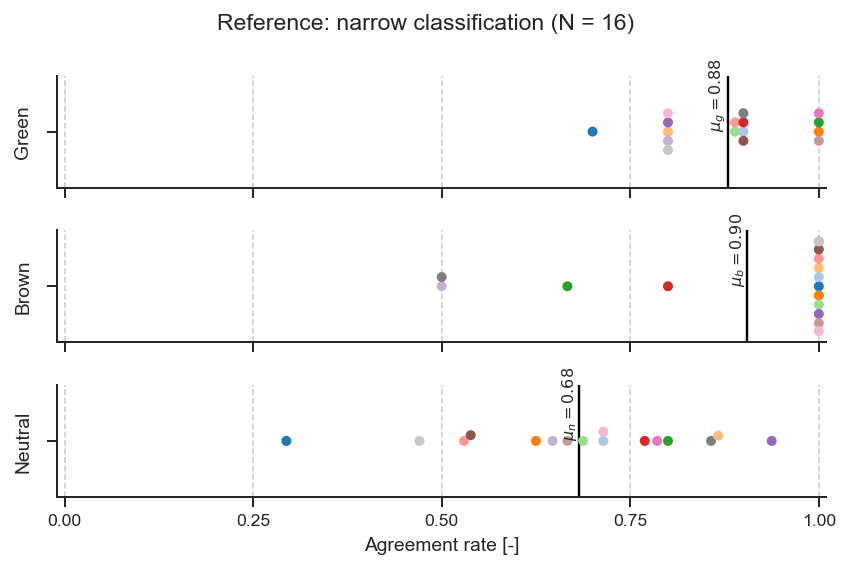

In [34]:
color = "tab20"
alpha = 1
show_legend = False

for drop_outlier_responses in response_data_sets:
    for show_legend in [True, False]:

        for version, df_plot in dfs.items():

            # optionally drop outliers
            if drop_outlier_responses is not None:
                df_plot = df_plot[
                    ~df_plot["RecipientName"].isin(drop_outlier_responses)
                ]

            fig, axes = plt.subplots(nrows=3, sharex=True)

            # swarmplots (one point is one rater)
            sns.swarmplot(
                y=[""] * len(df_plot),
                x=df_plot["AccuracyGreen"],
                hue=df_plot["RecipientName"],
                palette=color,
                alpha=alpha,
                ax=axes[0],
            )
            sns.swarmplot(
                y=[""] * len(df_plot),
                x=df_plot["AccuracyBrown"],
                hue=df_plot["RecipientName"],
                palette=color,
                alpha=alpha,
                ax=axes[1],
            )
            sns.swarmplot(
                y=[""] * len(df_plot),
                x=df_plot["AccuracyNeutral"],
                hue=df_plot["RecipientName"],
                palette=color,
                alpha=alpha,
                ax=axes[2],
            )

            # mean accuracies per category
            mean_acc_green = df_plot["AccuracyGreen"].mean()
            mean_acc_brown = df_plot["AccuracyBrown"].mean()
            mean_acc_neutral = df_plot["AccuracyNeutral"].mean()

            # averages
            axes[0].axvline(mean_acc_green, color="k")
            axes[1].axvline(mean_acc_brown, color="k")
            axes[2].axvline(mean_acc_neutral, color="k")

            # annotations
            y_text = 0
            axes[0].text(
                mean_acc_green,
                y_text,
                "$\mu_g = {:.2f}$".format(mean_acc_green),
                rotation=90,
                va="bottom",
                ha="right",
                fontsize=8,
            )
            axes[1].text(
                mean_acc_brown,
                y_text,
                "$\mu_b = {:.2f}$".format(mean_acc_brown),
                rotation=90,
                va="bottom",
                ha="right",
                fontsize=8,
            )
            axes[2].text(
                mean_acc_neutral,
                y_text,
                "$\mu_n = {:.2f}$".format(mean_acc_neutral),
                rotation=90,
                va="bottom",
                ha="right",
                fontsize=8,
            )

            # labels
            axes[0].set_ylabel("Green")
            axes[0].set_xlabel(None)
            axes[1].set_ylabel("Brown")
            axes[1].set_xlabel(None)
            axes[2].set_ylabel("Neutral")
            axes[2].set_xlabel("Agreement rate [-]")

            # axis
            plt.xticks(np.arange(0, 1.25, 0.25))
            plt.xlim(-0.01, 1.01)

            # grid lines
            for ax in axes:
                ax.grid(axis="x", which="major", linestyle="--")

            # legend
            for ax in axes:
                ax.legend([], [], frameon=False)

            if show_legend:
                plotting_utils.move_legend_to_right(axes[1], scale=0.5)

            # layout
            plt.suptitle(
                "Reference: {} classification (N = {})".format(version, len(df_plot))
            )
            sns.despine()
            plt.tight_layout()

            # save
            if drop_outlier_responses is None:
                msg = "including_outliers"
            else:
                msg = "excluding_outliers"
            plt.savefig(
                os.path.join(
                    useful_paths.figure_dir,
                    "survey",
                    "classification_accuracy_per_category_{}_legend_{}_{}.png".format(
                        version, show_legend, msg
                    ),
                ),
                bbox_inches="tight",
                dpi=300,
            )